# Feature Extraction — φ(z)

Demonstrates and numerically checks `src/deployment_reliability/features.py` (DESIGN.md §5–§6): the five recommended logit-derived features MSP, logit margin, normalized entropy, energy score, and logit L2 norm.

In [1]:
import os
import sys

import matplotlib.pyplot as plt
import torch

sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
torch.manual_seed(0)
%matplotlib inline

from deployment_reliability.features import (
    DEFAULT_FEATURE_NAMES, energy_score, featurize, logit_l2_norm,
    logit_margin, msp, normalized_entropy,
)

C = 1000
print("feature order:", DEFAULT_FEATURE_NAMES)

feature order: ('msp', 'logit_margin', 'normalized_entropy', 'energy_score', 'logit_l2_norm')


## Check 1 — Uniform logits closed-form values

At `z = 0` (all classes equally likely), every feature has a known closed form. This is the sanity-check floor: if these don't match, nothing downstream can be trusted.

In [2]:
z_uniform = torch.zeros(C)
vals = {
    "msp": msp(z_uniform).item(),
    "logit_margin": logit_margin(z_uniform).item(),
    "normalized_entropy": normalized_entropy(z_uniform).item(),
    "energy_score": energy_score(z_uniform).item(),
    "logit_l2_norm": logit_l2_norm(z_uniform).item(),
}
for k, v in vals.items():
    print(f"{k:20s} = {v:.6f}")

import math
assert math.isclose(vals["msp"], 1.0 / C, rel_tol=1e-5), "MSP should be 1/C on uniform logits"
assert math.isclose(vals["logit_margin"], 0.0, abs_tol=1e-6), "margin should be 0 when all logits tie"
assert math.isclose(vals["normalized_entropy"], 1.0, rel_tol=1e-4), "entropy should be maximal (1.0) on a uniform distribution"
assert math.isclose(vals["energy_score"], math.log(C), rel_tol=1e-5), "energy(T=1) should equal log(C) on uniform logits"
assert math.isclose(vals["logit_l2_norm"], 0.0, abs_tol=1e-6), "L2 norm should be 0 when all logits are 0"
print("\nAll closed-form checks PASSED")

msp                  = 0.001000
logit_margin         = 0.000000
normalized_entropy   = 1.000000
energy_score         = 6.907755
logit_l2_norm        = 0.000000

All closed-form checks PASSED


### What the uniform-logit floor establishes

These aren't arbitrary numbers to match — they're the theoretical floor every one of these features can produce, and the anchor that later notebooks' real numbers should be read against. MSP = 1/C = 0.001 is literally the lowest MSP can go (uniform mass over 1000 classes); when notebook 06/07 later report a real ResNet-50's MSP around 0.44 on a correctly classified photo, that's ~440x this floor, not just "some positive number." Normalized entropy = 1.0 is the mirror-image ceiling (maximal uncertainty), and energy_score = log(C) = 6.9078 exactly is itself informative: since energy is log C at T=1 under a uniform distribution regardless of C's actual value, a real backbone's energy score is only interpretable relative to this per-C baseline, not in absolute terms — which is exactly why DESIGN.md §5.3 flags energy as needing calibration when comparing across backbones with different C. Getting these five numbers exactly right here is the precondition for trusting anything computed downstream: combiner (02), calibration (03), and router (04) all consume φ(z) without re-deriving it, so a silent sign or scale error here would propagate invisibly rather than throwing an error.

## Check 2 — Response to increasing peak sharpness (figure)

Sweep a single class's logit from 0 to 20 (rest held at 0) and track how each feature responds. MSP, margin, and energy should rise; normalized entropy should fall.

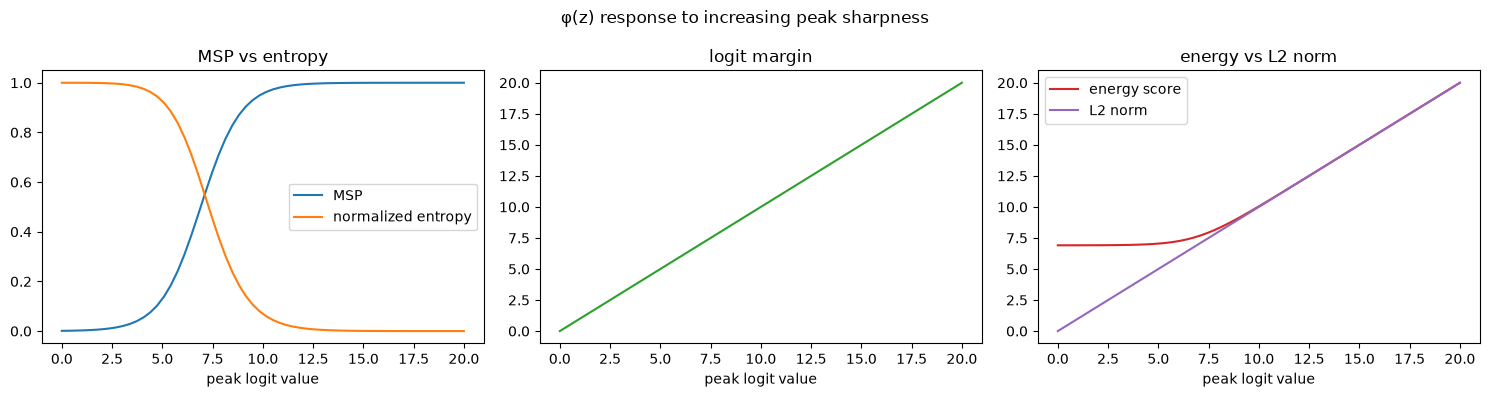

All monotonicity checks PASSED


In [3]:
peaks = torch.linspace(0, 20, 60)
logits_sweep = torch.zeros(len(peaks), C)
logits_sweep[:, 0] = peaks

phi_sweep = featurize(logits_sweep)
msp_v, margin_v, ent_v, energy_v, norm_v = [phi_sweep[:, i] for i in range(5)]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(peaks, msp_v, label="MSP")
axes[0].plot(peaks, ent_v, label="normalized entropy")
axes[0].set_xlabel("peak logit value"); axes[0].legend(); axes[0].set_title("MSP vs entropy")
axes[1].plot(peaks, margin_v, color="tab:green")
axes[1].set_xlabel("peak logit value"); axes[1].set_title("logit margin")
axes[2].plot(peaks, energy_v, color="tab:red", label="energy score")
axes[2].plot(peaks, norm_v, color="tab:purple", label="L2 norm")
axes[2].set_xlabel("peak logit value"); axes[2].legend(); axes[2].set_title("energy vs L2 norm")
fig.suptitle("\u03c6(z) response to increasing peak sharpness")
plt.tight_layout(); plt.show()

assert (msp_v.diff() >= -1e-6).all(), "MSP should be non-decreasing as the peak sharpens"
assert (margin_v.diff() >= -1e-6).all(), "margin should be non-decreasing as the peak sharpens"
assert (ent_v.diff() <= 1e-6).all(), "normalized entropy should be non-increasing as the peak sharpens"
assert (energy_v.diff() >= -1e-6).all(), "energy score should be non-decreasing as the peak sharpens"
print("All monotonicity checks PASSED")

### Reading the sweep: saturation is the point, not a flaw

MSP and margin both rise as the peak sharpens, but not identically: MSP is squeezed through a softmax and approaches its ceiling of 1.0 asymptotically, while margin is a raw logit gap with no such ceiling — it keeps growing linearly. This is precisely the failure mode DESIGN.md §5.1 names for MSP ("saturates near 1.0 under temperature miscalibration, losing resolution between high-confidence-correct and high-confidence-wrong cases") and the reason margin is kept as a companion feature rather than treated as redundant with MSP: two predictions that both have MSP ≈ 0.999 can still have very different margins, and margin keeps distinguishing them where MSP has run out of room. Energy score and L2 norm both grow monotonically with the peak too, but for a different reason than MSP/margin — they're magnitude signals (§5.3-§5.4), tracking "how hard did the network react" rather than "how concentrated is the winner," which is why they don't saturate the same way and why the combiner (02) treats them as a distinct source of information rather than a redundant copy of MSP.

## Check 3 — Batched `featurize()` consistency

`featurize` must agree exactly with calling each feature function individually, and must batch correctly over an arbitrary leading dimension.

In [4]:
torch.manual_seed(1)
batch = torch.randn(32, C) * 3
phi = featurize(batch)
assert phi.shape == (32, 5), phi.shape

expected = torch.stack([
    msp(batch), logit_margin(batch), normalized_entropy(batch),
    energy_score(batch), logit_l2_norm(batch),
], dim=-1)
assert torch.allclose(phi, expected, atol=1e-6)
print("featurize() shape:", tuple(phi.shape))
print("featurize() matches individual feature functions: PASSED")
print("\nper-feature stats over the random batch:")
for name, col in zip(DEFAULT_FEATURE_NAMES, phi.T):
    print(f"  {name:20s} mean={col.mean():.4f}  std={col.std():.4f}")

featurize() shape: (32, 5)
featurize() matches individual feature functions: PASSED

per-feature stats over the random batch:
  msp                  mean=0.2439  std=0.1450
  logit_margin         mean=0.6912  std=0.7787
  normalized_entropy   mean=0.5054  std=0.0856
  energy_score         mean=11.1765  std=0.4158
  logit_l2_norm        mean=95.1989  std=2.1428


### Why the per-feature scales matter for what comes next

The five features live on wildly different numeric scales even on the same random batch: MSP sits in [0,1] with mean 0.24, while logit_l2_norm averages ~95 with a std of ~2.14 — nearly 400x MSP's own scale. That's expected (L2 norm is a sum over 1000 squared logit values; MSP is a single softmax probability), but it's the reason `WeightedLinearCombiner` (02) can't just sum φ(z) raw: an unnormalized L2 norm term would numerically swamp every other feature regardless of how informative they are. This cell's stats are the concrete evidence for why the combiner's min-max normalization step exists at all, not just a design choice asserted in DESIGN.md §8 without justification.

## Summary

- The closed-form checks anchor every feature to a known, C-dependent floor/ceiling (MSP=1/C, entropy=1.0, energy=log C at T=1) — the reference point later real-backbone numbers (notebooks 06+) are implicitly compared against.
- All five features move in the theoretically expected direction as predictions sharpen, and do so at different rates and with different ceilings (MSP saturates, margin doesn't) — confirming they carry complementary rather than redundant information, which is the premise the 5-feature set in DESIGN.md §6 depends on.
- `featurize()` is consistent with, and batches correctly over, the individual feature functions, and the per-feature scale spread observed here (MSP ~0.24 vs. L2 norm ~95) is the concrete reason the next stage normalizes before combining.

If any of these checks had failed — a wrong closed-form value, a non-monotonic sweep, or a `featurize()`/individual-function mismatch — every downstream notebook's numbers would be unreliable without any obvious symptom, since combiner/calibration/router all consume φ(z) as a black box. That is why this notebook, despite covering the simplest stage in the pipeline, gets the same rigor as the real-data evaluations later on.

Next: `02_combiner.ipynb` combines these five features into a single score S.